# Chapter 5 — Bayesian Inference

**STAT 418 · Computational Data Science** · runnable companion to the
[Chapter 5 webbook](../../Website/part3_bayesian/chapter5/index.rst).

This chapter makes the course's second great shift: from **frequentist** questions
about *procedures* ("what would happen if we repeated this experiment?") to
**Bayesian** questions about *beliefs* ("what should we believe given this
evidence?"). Parameters stop being fixed unknowns and become uncertain quantities
with probability distributions. The computational target moves from the sampling
distribution to the **posterior** $p(\theta \mid y) \propto p(y \mid \theta)\,p(\theta)$.

Nothing from Chapters 3–4 is discarded: the **likelihood** that powered maximum
likelihood now powers Bayesian updating; the **Monte Carlo** of Chapter 2 becomes
the engine of MCMC; the **bootstrap** of Chapter 4 has a Bayesian cousin in
posterior-predictive simulation; and the **exponential families** of §3.1 are
exactly the distributions that admit elegant **conjugate priors**.

We run the whole arc on **real data**, loaded straight from the course bucket.

## Learning outcomes
By the end you can:
1. Update a prior to a posterior by **grid approximation** and by **conjugate**
   algebra, and read every summary (mean, mode, credible interval, exceedance
   probability) off the posterior.
2. Choose priors — conjugate, weakly informative, informative — and quantify how
   the data weight $w = n/(n+n_0)$ governs **prior sensitivity** and **shrinkage**.
3. Build **credible intervals** (equal-tail vs highest-density), answer directional
   and **ROPE** hypotheses, and form **posterior-predictive** intervals.
4. Explain why a **Markov chain** can have a posterior as its stationary
   distribution, and code **Metropolis–Hastings** and **Gibbs** from scratch.
5. Fit real models in **PyMC**, read **ArviZ** diagnostics ($\hat R$, ESS,
   divergences), compare models with **WAIC / LOO**, and (optional) pool groups with
   a **hierarchical** model.

## Section map
| § | Topic | Real-data worked example |
|---|-------|--------------------------|
| 5.1 | Bayesian foundations | Grid posterior for Curry's free-throw rate (299/324) |
| 5.2 | Priors & conjugate analysis | Beta-Binomial + sensitivity, Normal-Normal (Michelson), Poisson-Gamma, Dirichlet election, weakly-informative recipe |
| 5.3 | Credible intervals & decisions | Beta(35,3): ETI vs HDI, directional, ROPE, predictive |
| 5.4 | Markov chains | Three-state weather chain → stationary distribution |
| 5.5 | MCMC algorithms | Metropolis-Hastings (from scratch) + Gibbs (Michelson NIG) |
| 5.6 | Probabilistic programming (PyMC) | Workflow + **Titanic** Bayesian logistic + Poisson regression |
| 5.7 | Model comparison | WAIC / LOO: Poisson vs Negative-Binomial |
| 5.8 | Hierarchical models *(optional / self-study)* | NBA partial pooling — does shrinkage pay off? |
| 5.9 | Summary & connections | formula table → the rest of the course |

> **The free-throw thread.** Several examples use Stephen Curry's 2023-24 free
> throws. Free throws (fixed 15-ft distance, no defender, identical routine) satisfy
> the Beta-Binomial's assumption of **one constant success probability over
> exchangeable iid trials** — unlike three-pointers, whose difficulty swings shot to
> shot. That is *why* the conjugate model is well specified here.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize_scalar
from scipy.special import logsumexp
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline

np.random.seed(418)            # reproducibility (STYLE.md contract)
plt.rcParams.update({
    'figure.figsize': (7.2, 4.2), 'figure.dpi': 110,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})
BLUE, RED, GREEN, ORANGE, PURPLE = '#4C72B0', '#C44E52', '#55A868', '#DD8452', '#8172B3'

# Course data bucket: every Chapter 5 dataset lives here (no repo needed).
BASE = ('https://pqyjaywwccbnqpwgeiuv.supabase.co/storage/v1/object/public/'
        'STAT%20418%20Images/Data/Chapter5/')
def url(name):
    return BASE + name

print('environment ready · numpy', np.__version__, '· pandas', pd.__version__)

environment ready · numpy 1.26.4 · pandas 2.3.3


## Section 5.1 — Foundations of Bayesian Inference

Bayes' theorem for a parameter $\theta$ is the whole framework on one line:

$$ \underbrace{p(\theta \mid y)}_{\text{posterior}} \;=\;
   \frac{\overbrace{p(y \mid \theta)}^{\text{likelihood}}\;
         \overbrace{p(\theta)}^{\text{prior}}}
        {\underbrace{\int p(y\mid\theta)\,p(\theta)\,d\theta}_{\text{evidence (a constant in }\theta)}}
   \;\propto\; p(y \mid \theta)\,p(\theta). $$

The posterior **is** the inference: every estimate, interval, and probability
statement is a summary of it. For most models the evidence integral is intractable,
but in **one or two dimensions** we can sidestep it with **grid approximation** —
evaluate prior × likelihood on a fine grid of $\theta$, normalize the weights to sum
to one, and then *every* summary is a weighted sum.

**Running example.** Stephen Curry's 2023-24 regular-season free throws: $k=299$
makes of $n=324$ attempts. With a flat $\text{Beta}(1,1)$ prior the data dominate,
and there is a closed-form conjugate posterior $\text{Beta}(300,26)$ to validate the
grid against. The decision question: *is Curry truly an elite ($\theta>0.90$) shooter?*


In [2]:
# Real data: 2023-24 game-by-game free-throw log; take Curry's season totals.
ft = pd.read_csv(url('nba_freethrows_2023_24.csv'))
curry = ft[ft['player'] == 'Stephen Curry'].reset_index(drop=True)
k, n = int(curry['cum_ft'].iloc[-1]), int(curry['cum_fta'].iloc[-1])   # (299, 324)
print(f'Curry 2023-24 free throws: {k}/{n} = {k/n:.3f}  (flat Beta(1,1) prior)')

# ---- Grid approximation (done on the log scale for stability) ----------------
grid = np.linspace(1e-4, 1 - 1e-4, 1000)
log_unnorm = stats.beta.logpdf(grid, 1, 1) + stats.binom.logpmf(k, n, grid)
w = np.exp(log_unnorm - logsumexp(log_unnorm))        # normalized weights, sum to 1

# Every summary is now a weighted sum over the grid:
mean = np.sum(grid * w)
var  = np.sum((grid - mean) ** 2 * w)
mode = grid[np.argmax(w)]
cdf  = np.cumsum(w)
lo, hi = grid[np.searchsorted(cdf, [0.025, 0.975])]   # credible interval via empirical CDF
p_elite = w[grid > 0.90].sum()                        # exceedance prob = mass past 0.90

# ---- Exact conjugate posterior Beta(1+k, 1+n-k) = Beta(300, 26) for validation --
exact = stats.beta(1 + k, 1 + (n - k))
print(f'Exact posterior: Beta({1+k}, {1+n-k})\n')
print(f"  {'quantity':>14} {'grid':>9} {'exact':>9}")
print(f"  {'mean':>14} {mean:>9.4f} {exact.mean():>9.4f}")
print(f"  {'mode':>14} {mode:>9.4f} {(1 + k - 1) / (1 + 1 + n - 2):>9.4f}")
print(f"  {'95% CI low':>14} {lo:>9.4f} {exact.ppf(0.025):>9.4f}")
print(f"  {'95% CI high':>14} {hi:>9.4f} {exact.ppf(0.975):>9.4f}")
print(f"  {'P(theta>0.90)':>14} {p_elite:>9.4f} {exact.sf(0.90):>9.4f}")
print('\nGrid matches the closed form; P(theta>0.90) ~ 0.91 -> with high posterior')
print('probability Curry is a truly elite free-throw shooter.')

Curry 2023-24 free throws: 299/324 = 0.923  (flat Beta(1,1) prior)
Exact posterior: Beta(300, 26)

        quantity      grid     exact
            mean    0.9202    0.9202
            mode    0.9228    0.9228
      95% CI low    0.8888    0.8885
     95% CI high    0.9469    0.9471
   P(theta>0.90)    0.9024    0.9056

Grid matches the closed form; P(theta>0.90) ~ 0.91 -> with high posterior
probability Curry is a truly elite free-throw shooter.


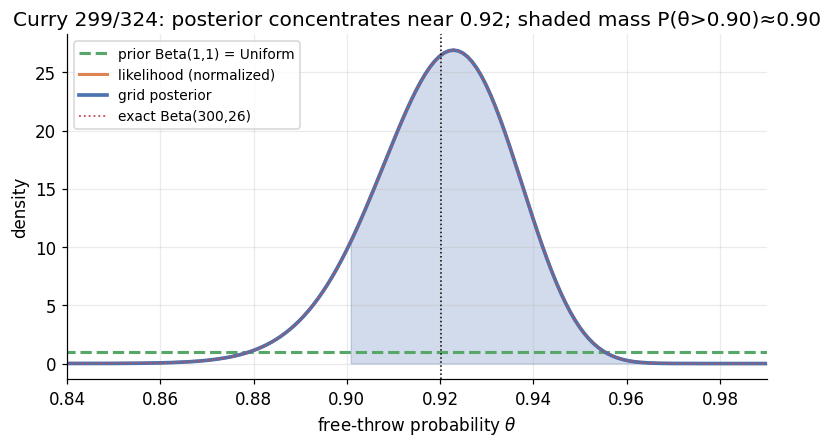

In [3]:
# Figure: prior, (scaled) likelihood, and the grid posterior; shade P(theta>0.90).
like = np.exp(stats.binom.logpmf(k, n, grid))
like_scaled = like / (like.sum() * (grid[1] - grid[0]))   # scale to a density for display
post_density = w / (grid[1] - grid[0])                 # weights -> density
fig, ax = plt.subplots()
ax.plot(grid, np.ones_like(grid), color=GREEN, lw=2, ls='--', label='prior Beta(1,1) = Uniform')
ax.plot(grid, like_scaled, color=ORANGE, lw=2, label='likelihood (normalized)')
ax.plot(grid, post_density, color=BLUE, lw=2.4, label='grid posterior')
ax.plot(grid, exact.pdf(grid), color=RED, lw=1.2, ls=':', label='exact Beta(300,26)')
sel = grid > 0.90
ax.fill_between(grid[sel], 0, post_density[sel], color=BLUE, alpha=0.25)
ax.axvline(mean, color='k', lw=1, ls=':')
ax.set_xlim(0.84, 0.99); ax.set_xlabel(r'free-throw probability $\theta$')
ax.set_ylabel('density')
ax.set_title(f'Curry 299/324: posterior concentrates near 0.92; shaded mass P(θ>0.90)≈{p_elite:.2f}')
ax.legend(loc='upper left', fontsize=9); plt.tight_layout(); plt.show()

**Read-out.** Hundreds of free throws collapsed to a posterior tightly centered at
$\hat\theta_{\text{post}} \approx 0.920$, and the grid reproduced the closed-form
$\text{Beta}(300,26)$ to four decimals — a reassuring check that the normalization was
done right. The posterior answers the decision question *directly*:
$P(\theta > 0.90 \mid y) \approx 0.91$, a probability statement about the parameter that
a frequentist confidence interval cannot make. Grid approximation is the conceptual
on-ramp; for higher dimensions we will need conjugacy (§5.2) or MCMC (§5.4–5.6).


## Section 5.2 — Prior Specification & Conjugate Analysis

A **conjugate** prior is one for which the posterior stays in the same family, so the
update is pure algebra. The headline cases — all exponential-family likelihoods from
§3.1 — are **Beta-Binomial**, **Normal-Normal**, **Normal-Inverse-Gamma**,
**Poisson-Gamma**, and **Multinomial-Dirichlet**. The recurring idea is that the
**posterior mean is a precision-weighted average** of the prior mean and the data,

$$ \text{posterior mean} \;=\; w\cdot(\text{MLE}) + (1-w)\cdot(\text{prior mean}),
   \qquad w = \frac{n}{n + n_0}, $$

where $n_0$ is the prior's strength in pseudo-observations. We work the families on
real data and then make $w$ — the engine of prior sensitivity and shrinkage —
explicit.

### Beta-Binomial: the conjugate update

A $\text{Beta}(a_0,b_0)$ prior plus $k$ successes in $n$ trials gives a
$\text{Beta}(a_0+k,\;b_0+n-k)$ posterior — *add successes to $a_0$, failures to $b_0$*.
We switch to Curry's **first 36 free throws** (34/36): a *small* $n$ where the prior
can still move the posterior, and where the posterior is heavily **left-skewed**
(mode 0.944, pressed against 1) — which is exactly why the equal-tail and
highest-density intervals will differ in §5.3.


In [4]:
# A reusable highest-density-interval helper (used here and in 5.3).
def hdi(dist, mass=0.95):
    '''Narrowest interval holding `mass` probability of a scipy continuous dist.
    For a unimodal density its endpoints share equal density f(lo)=f(hi).'''
    res = minimize_scalar(lambda p: dist.ppf(p + mass) - dist.ppf(p),
                          bounds=(1e-9, 1 - mass - 1e-9), method='bounded')
    return float(dist.ppf(res.x)), float(dist.ppf(res.x + mass))

# Curry's first 36 free throws (the first game by which cumulative FTA reaches 30).
g0 = curry[curry['cum_fta'] >= 30].iloc[0]
k36, n36 = int(g0['cum_ft']), int(g0['cum_fta'])       # (34, 36)
a0, b0 = 1, 1                                           # flat prior
a, b = a0 + k36, b0 + (n36 - k36)                       # Beta(35, 3)
post = stats.beta(a, b)
print(f'Curry first {n36} FTA: {k36}/{n36} = {k36/n36:.3f}  ->  posterior Beta({a}, {b})')
print(f'  mean {post.mean():.3f}   sd {post.std():.3f}   mode {(a-1)/(a+b-2):.3f}  (left-skewed)')
print(f'  P(theta > 0.90) = {post.sf(0.90):.3f}')
et = (post.ppf(0.025), post.ppf(0.975))
hd = hdi(post)
print(f'  95% equal-tail : [{et[0]:.3f}, {et[1]:.3f}]')
print(f'  95% HDI        : [{hd[0]:.3f}, {hd[1]:.3f}]   <- shifted toward the mode')

Curry first 36 FTA: 34/36 = 0.944  ->  posterior Beta(35, 3)
  mean 0.921   sd 0.043   mode 0.944  (left-skewed)
  P(theta > 0.90) = 0.730
  95% equal-tail : [0.818, 0.983]
  95% HDI        : [0.836, 0.991]   <- shifted toward the mode


### Prior sensitivity: it is $n_0$ vs $n$, through the weight $w$

How much a prior moves the posterior is governed not by "small $n$" in the abstract but
by the prior strength $n_0=a_0+b_0$ **relative to** the data $n$. Same data, different
$n_0 \Rightarrow$ different conclusions. We compare four priors against Curry's early
(34/36) and full-season (299/324) data:

- **Flat** $\text{Beta}(1,1)$ and **Jeffreys** $\text{Beta}(.5,.5)$: $n_0 \approx 1\text{–}2$, so $w\approx 1$ — invisible at any $n$.
- **Skeptical** $\text{Beta}(28,8)$: league-average mean $0.78$, $n_0=36$. Exactly halfway at the early sample ($w=0.5$) — but indefensible for Curry (career $0.91$); the right default only for an *unknown* shooter.
- **Career** $\text{Beta}(3937,384)$: Curry's prior-season record, $n_0=4321$. It dominates and pins the SD near $0.004$ — a *defensible* strong prior because it is backed by 4321 real attempts.


In [5]:
# Four priors; n0 = a0 + b0 is the prior strength. Career prior built from the
# career file MINUS the 2023-24 season (the real prior-season evidence).
career = pd.read_csv(url('nba_freethrow_career.csv'))
cr = career[career['player'] == 'Stephen Curry'].iloc[0]
prior_mk = int(cr['career_ft']) - k          # career makes before 2023-24
prior_ms = (int(cr['career_fta']) - n) - prior_mk
priors = {
    'Flat (.50)':      (1.0, 1.0),
    'Jeffreys (.50)':  (0.5, 0.5),
    'Skeptical (.78)': (28.0, 8.0),
    'Career (.91)':    (float(prior_mk), float(prior_ms)),
}

def compare(kk, nn, label):
    print(f'\n{label}: data {kk}/{nn}, MLE = {kk/nn:.3f}')
    print(f"  {'prior':16s} {'n0':>6} {'w=n/(n+n0)':>11} {'mean':>7} {'sd':>7} {'P(>.90)':>8}")
    for name, (pa, pb) in priors.items():
        n0 = pa + pb
        ww = nn / (nn + n0)
        ps = stats.beta(pa + kk, pb + (nn - kk))
        print(f'  {name:16s} {n0:>6.0f} {ww:>11.3f} {ps.mean():>7.3f} {ps.std():>7.3f} {ps.sf(0.90):>8.2f}')

compare(k36, n36, 'EARLY (first 36 FTA)')
compare(k, n, 'FULL season')
print('\nThe fixed skeptical prior (n0=36) is halfway at n=36 (w=.5) but overwhelmed at')
print('n=324 (w=.9); the career prior (n0=4321) dominates at both. Set n0 to the prior')
print('EVIDENCE you actually have -- the career prior earns its n0; generic skepticism does not.')


EARLY (first 36 FTA): data 34/36, MLE = 0.944
  prior                n0  w=n/(n+n0)    mean      sd  P(>.90)
  Flat (.50)            2       0.947   0.921   0.043     0.73
  Jeffreys (.50)        1       0.973   0.932   0.041     0.81
  Skeptical (.78)      36       0.500   0.861   0.040     0.17
  Career (.91)       4321       0.008   0.911   0.004     0.99

FULL season: data 299/324, MLE = 0.923
  prior                n0  w=n/(n+n0)    mean      sd  P(>.90)
  Flat (.50)            2       0.994   0.920   0.015     0.91
  Jeffreys (.50)        1       0.997   0.922   0.015     0.92
  Skeptical (.78)      36       0.900   0.908   0.015     0.72
  Career (.91)       4321       0.070   0.912   0.004     1.00

The fixed skeptical prior (n0=36) is halfway at n=36 (w=.5) but overwhelmed at
n=324 (w=.9); the career prior (n0=4321) dominates at both. Set n0 to the prior
EVIDENCE you actually have -- the career prior earns its n0; generic skepticism does not.


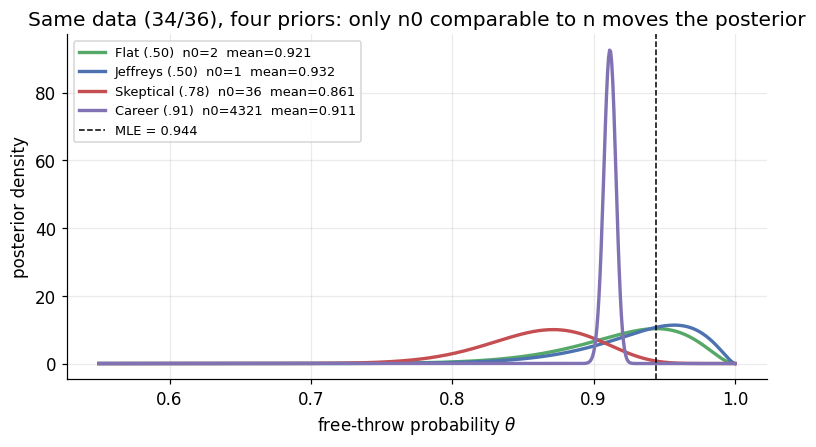

In [6]:
# Figure: same early data (34/36), four priors -> four posteriors.
xx = np.linspace(0.55, 1.0, 600)
fig, ax = plt.subplots()
colors = {'Flat (.50)': GREEN, 'Jeffreys (.50)': BLUE,
          'Skeptical (.78)': RED, 'Career (.91)': PURPLE}
for name, (pa, pb) in priors.items():
    ps = stats.beta(pa + k36, pb + (n36 - k36))
    n0 = pa + pb
    ax.plot(xx, ps.pdf(xx), color=colors[name], lw=2.2,
            label=f'{name}  n0={n0:.0f}  mean={ps.mean():.3f}')
ax.axvline(k36 / n36, color='k', lw=1, ls='--', label=f'MLE = {k36/n36:.3f}')
ax.set_xlabel(r'free-throw probability $\theta$'); ax.set_ylabel('posterior density')
ax.set_title('Same data (34/36), four priors: only n0 comparable to n moves the posterior')
ax.legend(fontsize=8.5); plt.tight_layout(); plt.show()

### Normal-Normal: Michelson's speed of light, and a bias a credible interval cannot see

For Normal data with **known** $\sigma$ and a flat (Jeffreys) prior, the posterior for
the mean collapses to $\mathcal N(\bar y,\,\sigma^2/n)$ — *identical* to the
frequentist $z$-interval. We use A. A. Michelson's 100 determinations of the speed of
light (June–July 1879; `Speed` is km/s − 299000). The likelihood is tight (SE ≈ 7.9
km/s) but centered in the **wrong place**: Michelson measured in air, so the honest
comparison value is Stigler's (1977) air-corrected target $734.5$ — and the posterior
sits about **15 SE** above it. That gap is **systematic error**, which a credible
interval (which only captures random scatter) cannot detect.


In [7]:
morley = pd.read_csv(url('morley.csv'))
speed = morley['Speed'].to_numpy(float)
n_m = len(speed); ybar = speed.mean(); s = speed.std(ddof=1); se = s / np.sqrt(n_m)
print(f'Michelson 1879: n={n_m}, mean {299000+ybar:.1f} km/s, SD {s:.2f}, SE {se:.2f}\n')

# Normal-Normal, sigma known = s, Jeffreys prior -> N(ybar, se^2) = the z-interval.
post_mu = stats.norm(ybar, se)
clo, chi = post_mu.ppf(0.025), post_mu.ppf(0.975)
print(f'[Normal-Normal] posterior N({299000+ybar:.1f}, {se:.2f}^2)')
print(f'  95% credible interval: [{299000+clo:.1f}, {299000+chi:.1f}] km/s')

# Even a real, distant historical prior (Foucault 1862, 298,000 +/- 500) is swamped:
mu0_f, sd0_f = 298000 - 299000, 500.0
wf = (n_m / s**2) / (1 / sd0_f**2 + n_m / s**2)
print(f'  Foucault 1862 prior (298,000+/-500): data weight w={wf:.4f} -> indistinguishable from Jeffreys\n')

# Bias vs each candidate "truth" -- a modelling choice, not a given.
targets = {'naive full-refraction': 705.0, 'Stigler air-corrected': 734.5, 'modern vacuum': 792.5}
lo99, hi99 = post_mu.ppf(5e-5), post_mu.ppf(1 - 5e-5)         # 99.99% interval
for name, t in targets.items():
    inside = lo99 <= t <= hi99
    print(f'  vs {name:22s} {299000+t:9.1f}: bias {ybar-t:+6.1f} km/s = '
          f'{(ybar-t)/se:4.1f} SE   in 99.99% CI? {inside}')
print('\n-> The posterior is PRECISE but INACCURATE: no credibility level you would report')
print('   contains the air-corrected target. Random-scatter intervals are blind to bias.')

Michelson 1879: n=100, mean 299852.4 km/s, SD 79.01, SE 7.90

[Normal-Normal] posterior N(299852.4, 7.90^2)
  95% credible interval: [299836.9, 299867.9] km/s
  Foucault 1862 prior (298,000+/-500): data weight w=0.9998 -> indistinguishable from Jeffreys

  vs naive full-refraction   299705.0: bias +147.4 km/s = 18.7 SE   in 99.99% CI? False
  vs Stigler air-corrected   299734.5: bias +117.9 km/s = 14.9 SE   in 99.99% CI? False
  vs modern vacuum           299792.5: bias  +59.9 km/s =  7.6 SE   in 99.99% CI? False

-> The posterior is PRECISE but INACCURATE: no credibility level you would report
   contains the air-corrected target. Random-scatter intervals are blind to bias.


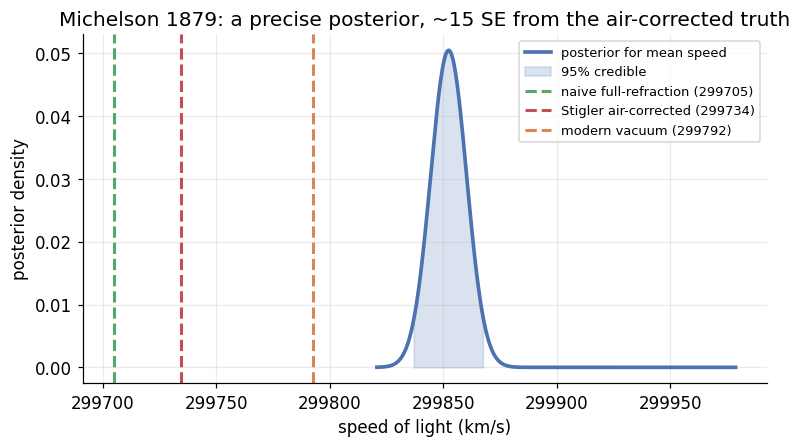

In [8]:
# Figure: the tight Normal posterior vs the candidate "truths".
xx = np.linspace(ybar - 4*se, ybar + 16*se, 400)
fig, ax = plt.subplots()
ax.plot(299000 + xx, post_mu.pdf(xx), color=BLUE, lw=2.4, label='posterior for mean speed')
ax.fill_between(299000 + xx, 0, post_mu.pdf(xx),
                where=(xx >= clo) & (xx <= chi), color=BLUE, alpha=0.2, label='95% credible')
tcol = {'naive full-refraction': GREEN, 'Stigler air-corrected': RED, 'modern vacuum': ORANGE}
for name, t in targets.items():
    ax.axvline(299000 + t, color=tcol[name], lw=2, ls='--',
               label=f'{name} ({299000+t:.0f})')
ax.set_xlabel('speed of light (km/s)'); ax.set_ylabel('posterior density')
ax.set_title('Michelson 1879: a precise posterior, ~15 SE from the air-corrected truth')
ax.legend(fontsize=8.5); plt.tight_layout(); plt.show()

### Poisson-Gamma and Multinomial-Dirichlet: two more conjugate families

**Poisson-Gamma.** Counts $y_i \sim \text{Poisson}(\lambda)$ with a $\text{Gamma}(a_0,b_0)$
prior on the rate give a $\text{Gamma}(a_0+\sum y_i,\; b_0+n)$ posterior. We reuse the
free-throw thread from a *count* angle: Curry's **per-game free-throw attempts**.

**Multinomial-Dirichlet.** The last conjugate family, for $>2$ categories: a
$\text{Dir}(\boldsymbol\alpha_0)$ prior plus multinomial counts gives
$\text{Dir}(\boldsymbol\alpha_0+\text{counts})$. We use a three-candidate election poll
to show that **a point estimate cannot answer a probabilistic question** — *plurality*
and *majority* are different events with very different posterior probabilities.


In [9]:
# --- Poisson-Gamma: Curry's per-game FT ATTEMPTS as counts -----------------
counts = curry['fta'].to_numpy(int)
ng, S = len(counts), counts.sum()
a0g, b0g = 2.0, 0.5                                   # weak Gamma prior, mean a0/b0 = 4
ag, bg = a0g + S, b0g + ng                            # Gamma posterior (rate b)
post_lam = stats.gamma(ag, scale=1/bg)
print(f'Poisson-Gamma: {ng} games, total FTA {S}, mean/game {counts.mean():.2f}')
print(f'  prior Gamma({a0g:.0f}, {b0g:.1f}) mean {a0g/b0g:.1f}  ->  posterior Gamma({ag:.0f}, {bg:.1f})')
print(f'  posterior mean rate {post_lam.mean():.3f} attempts/game  '
      f'95% CI [{post_lam.ppf(.025):.2f}, {post_lam.ppf(.975):.2f}]  (MLE {counts.mean():.3f})')

# --- Multinomial-Dirichlet: a 3-candidate poll (illustrative counts) --------
cand = ('A', 'B', 'C')
votes = np.array([215, 180, 105])                     # n = 500
alpha0 = np.array([42.0, 38.0, 20.0])                 # prior from a previous election, n0 = 100
alpha_n = alpha0 + votes                              # Dirichlet posterior
npoll, n0 = int(votes.sum()), int(alpha0.sum())
wd = npoll / (npoll + n0)
print(f'\nDirichlet poll: n={npoll}, prior n0={n0}, data weight w = {wd:.3f}')
post_share = alpha_n / alpha_n.sum()
for i, c in enumerate(cand):
    marg = stats.beta(alpha_n[i], alpha_n.sum() - alpha_n[i])   # each component is marginally Beta
    print(f'  cand {c}: posterior share {post_share[i]:.3f}  95% [{marg.ppf(.025):.3f}, {marg.ppf(.975):.3f}]')

# Monte Carlo over posterior draws: two DIFFERENT questions, one MLE answers neither.
rng = np.random.default_rng(418)
draws = rng.dirichlet(alpha_n, size=100_000)
p_majority  = (draws[:, 0] > 0.5).mean()
p_plurality = (draws[:, 0] > draws[:, 1:].max(axis=1)).mean()
print(f'  P(A wins a MAJORITY,  theta_A > 0.5)            = {p_majority:.4f}')
print(f'  P(A wins a PLURALITY, theta_A is the largest)   = {p_plurality:.4f}')
print('  -> A almost surely gets the MOST votes, but almost surely NOT more than half.')

Poisson-Gamma: 74 games, total FTA 324, mean/game 4.38
  prior Gamma(2, 0.5) mean 4.0  ->  posterior Gamma(326, 74.5)
  posterior mean rate 4.376 attempts/game  95% CI [3.91, 4.86]  (MLE 4.378)

Dirichlet poll: n=500, prior n0=100, data weight w = 0.833
  cand A: posterior share 0.428  95% [0.389, 0.468]
  cand B: posterior share 0.363  95% [0.325, 0.402]
  cand C: posterior share 0.208  95% [0.177, 0.242]
  P(A wins a MAJORITY,  theta_A > 0.5)            = 0.0002
  P(A wins a PLURALITY, theta_A is the largest)   = 0.9633
  -> A almost surely gets the MOST votes, but almost surely NOT more than half.


### Weakly informative priors: standardize first

When no conjugate form fits, the modern default is a **weakly informative** prior that
rules out absurd values while letting a reasonable amount of data dominate. The recipe
(Gelman et al. 2008; Gabry et al. 2019): **standardize** the outcome and predictors,
put the *same* default prior — e.g. $\mathcal N(0, 2.5)$ — on every standardized
coefficient, and **check with a prior-predictive simulation**. The same prior is
reasonable on the standardized scale and *wrong* on the raw scale; the scale is what
makes a prior sensible.


In [10]:
# Synthetic-but-concrete: exam score (SD 15) ~ study hours (SD 5); a real effect ~3 pt/hr.
SD_Y, SD_X, REAL, PRIOR_SD = 15.0, 5.0, 3.0, 2.5
beta_star = REAL * SD_X / SD_Y                         # raw 3 pt/hr -> standardized 1.0
half95 = stats.norm.ppf(0.975) * PRIOR_SD             # ~4.9
print(f'Effect-size map: a {REAL:.0f} pt/hr effect = standardized beta* = {beta_star:.1f} (SD_y per SD_x)\n')
print(f'Prior beta ~ N(0, {PRIOR_SD}): 95% within +/- {half95:.2f}')
print(f'  STANDARDIZED: +/- {half95:.2f} SD_y/SD_x  -> +/- {half95*SD_Y/SD_X:.1f} raw pt/hr; '
      f'a genuine {REAL:.0f} pt/hr sits comfortably inside -> good')
print(f'  RAW (no standardizing): +/- {half95:.2f} pt/hr only -> a real {REAL:.0f} pt/hr is at the '
      f'{stats.norm.sf(REAL/PRIOR_SD)*100:.0f}% tail -> too tight')

# Prior-predictive check on the quantity of interest (the tutoring effect itself):
eff = rng.normal(0, PRIOR_SD, 50_000) * SD_Y / SD_X   # standardized prior -> raw pt/hr
lo, hi = np.percentile(eff, [2.5, 97.5])
print(f'\nPrior-predictive on the effect: 95% within [{lo:.1f}, {hi:.1f}] pt/hr; '
      f'P(|effect|>15) = {np.mean(np.abs(eff) > 15):.2f}')
print('  -> spans realistic effects while ruling out the absurd. The prior is identical;')
print('     STANDARDIZING is what makes its scale reasonable.')

Effect-size map: a 3 pt/hr effect = standardized beta* = 1.0 (SD_y per SD_x)

Prior beta ~ N(0, 2.5): 95% within +/- 4.90
  STANDARDIZED: +/- 4.90 SD_y/SD_x  -> +/- 14.7 raw pt/hr; a genuine 3 pt/hr sits comfortably inside -> good
  RAW (no standardizing): +/- 4.90 pt/hr only -> a real 3 pt/hr is at the 12% tail -> too tight

Prior-predictive on the effect: 95% within [-14.6, 14.6] pt/hr; P(|effect|>15) = 0.04
  -> spans realistic effects while ruling out the absurd. The prior is identical;
     STANDARDIZING is what makes its scale reasonable.


**Read-out.** Conjugacy turned every update into algebra: Beta-Binomial (add
makes/misses), Normal-Normal (precision-weighted mean), Poisson-Gamma (Curry attempts
$\approx 4.4$/game), Dirichlet (election shares). The unifying lesson is the weight
$w=n/(n+n_0)$: a prior moves the posterior only when its strength $n_0$ is comparable
to $n$, which is why the career prior ($n_0=4321$) bites and generic skepticism
($n_0=36$) is swamped by a full season. And two cautions the algebra cannot supply on
its own — Michelson's posterior is *precise but biased*, and a Dirichlet *point*
estimate answers neither "plurality" nor "majority" while the full posterior answers
both ($\approx 0.96$ vs $\approx 0.0002$).


## Section 5.3 — Credible Intervals & Posterior Decisions

A **credible interval** is the Bayesian interval: a 95% credible interval contains the
parameter with posterior probability 0.95 — a *direct* probability statement, unlike a
confidence interval (whose 95% refers to the procedure across repeated samples). Two
flavors:

- **Equal-tail interval (ETI):** chop 2.5% off each tail. Simple, but for a skewed
  posterior its endpoints have *unequal* density.
- **Highest-density interval (HDI):** the **narrowest** interval holding 95%; its
  endpoints share equal density. For a skewed posterior the HDI is shorter and shifts
  toward the mode.

All four §5.3 ideas read off **one** posterior — Curry's left-skewed
$\text{Beta}(35,3)$ from §5.2.


In [11]:
# One posterior drives everything: Beta(35, 3), mode 0.944 (left-skewed).
print(f'posterior Beta({a}, {b}), mode {(a-1)/(a+b-2):.3f}\n')

# --- ETI vs HDI (HDI endpoints share equal density -> narrower) ---
print('[intervals] 95% ETI vs HDI')
print(f'  ETI [{et[0]:.3f}, {et[1]:.3f}] width {et[1]-et[0]:.3f}  '
      f'f(lo)={post.pdf(et[0]):.3f}  f(hi)={post.pdf(et[1]):.3f}  (unequal)')
print(f'  HDI [{hd[0]:.3f}, {hd[1]:.3f}] width {hd[1]-hd[0]:.3f}  '
      f'f(lo)={post.pdf(hd[0]):.3f}  f(hi)={post.pdf(hd[1]):.3f}  (equal -> narrower)')

# --- Directional probabilities: one CDF eval per threshold ---
print('\n[directional]  P(theta > t) = 1 - F(t)')
for t, lbl in [(0.50, 'better than a coin'), (0.78, 'above league average'),
               (0.90, 'elite'), (0.95, 'near-perfect')]:
    print(f'  P(theta > {t:.2f}) = {post.sf(t):.3f}   ({lbl})')

# --- Posterior-predictive interval for the NEXT 20 free throws (Beta-Binomial) ---
m = 20
pred = stats.betabinom(m, a, b)
print(f'\n[predictive] next {m} FT: mean {pred.mean():.1f} makes, '
      f'95% PI [{pred.ppf(0.025):.0f}, {pred.ppf(0.975):.0f}]')
print('  The credible interval on theta is EPISTEMIC (uncertainty about the rate);')
print('  the predictive interval ALSO carries aleatoric shot-to-shot randomness.')

posterior Beta(35, 3), mode 0.944

[intervals] 95% ETI vs HDI
  ETI [0.818, 0.983] width 0.165  f(lo)=0.836  f(hi)=3.774  (unequal)
  HDI [0.836, 0.991] width 0.155  f(lo)=1.432  f(hi)=1.431  (equal -> narrower)

[directional]  P(theta > t) = 1 - F(t)
  P(theta > 0.50) = 1.000   (better than a coin)
  P(theta > 0.78) = 0.993   (above league average)
  P(theta > 0.90) = 0.730   (elite)
  P(theta > 0.95) = 0.282   (near-perfect)

[predictive] next 20 FT: mean 18.4 makes, 95% PI [15, 20]
  The credible interval on theta is EPISTEMIC (uncertainty about the rate);
  the predictive interval ALSO carries aleatoric shot-to-shot randomness.


In [12]:
# ROPE: a "region of practical equivalence" turns the posterior into a decision.
# ROPE = "practically league-average" = [0.76, 0.80] (0.78 +/- 0.02). Decision rule:
# HDI entirely outside ROPE -> reject; entirely inside -> accept; overlap -> undecided.
rope = (0.76, 0.80)
def rope_decision(aa, bb, label):
    d = stats.beta(aa, bb); lo, hi = hdi(d)
    if lo > rope[1] or hi < rope[0]:   out = 'Reject (meaningfully different)'
    elif lo > rope[0] and hi < rope[1]: out = 'Accept (practically average)'
    else:                               out = 'Undecided'
    print(f'  {label:30s} HDI [{lo:.3f}, {hi:.3f}] -> {out}')

print(f'[ROPE] {rope} (practically league-average):')
rope_decision(1 + k, 1 + (n - k), 'Curry, full season 299/324')          # elite
wb = career[career['player'] == 'Russell Westbrook'].iloc[0]
rope_decision(1 + int(wb['career_ft']), 1 + (int(wb['career_fta']) - int(wb['career_ft'])),
              'Westbrook, career 6109/7928')                             # genuinely average
hol = ft[ft['player'] == 'Jrue Holiday'].reset_index(drop=True)
gh = hol[hol['cum_fta'] >= 30].iloc[0]
rope_decision(1 + int(gh['cum_ft']), 1 + (int(gh['cum_fta']) - int(gh['cum_ft'])),
              f"Holiday, first {int(gh['cum_fta'])} FTA")                # small sample
print('  Same machinery, three verdicts: elite, average, and not-enough-data.')

[ROPE] (0.76, 0.8) (practically league-average):
  Curry, full season 299/324     HDI [0.890, 0.949] -> Reject (meaningfully different)
  Westbrook, career 6109/7928    HDI [0.761, 0.780] -> Accept (practically average)
  Holiday, first 31 FTA          HDI [0.687, 0.938] -> Undecided
  Same machinery, three verdicts: elite, average, and not-enough-data.


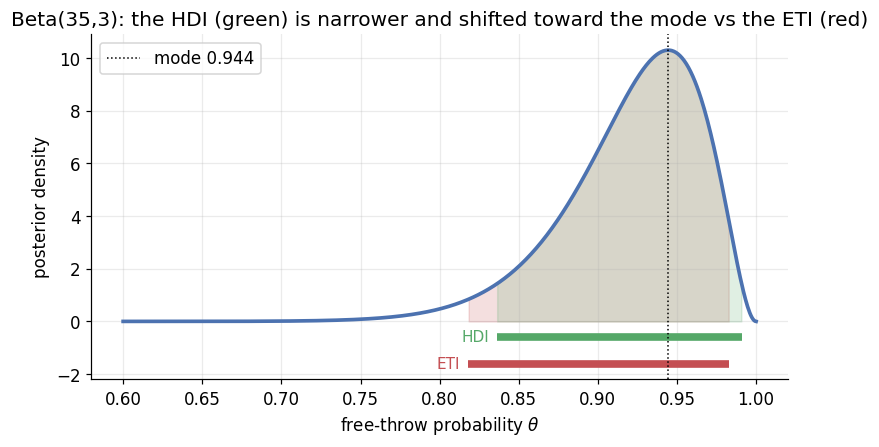

In [13]:
# Figure: Beta(35,3) with ETI vs HDI; note the HDI is narrower and shifted right.
xx = np.linspace(0.6, 1.0, 600)
fig, ax = plt.subplots()
ax.plot(xx, post.pdf(xx), color=BLUE, lw=2.4)
for (lo, hi), col, name, yo in [(et, RED, 'ETI', 1.0), (hd, GREEN, 'HDI', 0.0)]:
    sel = (xx >= lo) & (xx <= hi)
    ax.fill_between(xx, 0, post.pdf(xx), where=sel, color=col, alpha=0.18)
    ax.plot([lo, hi], [-0.6 - yo, -0.6 - yo], color=col, lw=5, solid_capstyle='butt')
    ax.text(lo - 0.005, -0.6 - yo, f'{name}', ha='right', va='center', color=col, fontsize=10)
ax.axvline((a-1)/(a+b-2), color='k', lw=1, ls=':', label='mode 0.944')
ax.set_xlabel(r'free-throw probability $\theta$'); ax.set_ylabel('posterior density')
ax.set_title('Beta(35,3): the HDI (green) is narrower and shifted toward the mode vs the ETI (red)')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()

**Read-out.** For the skewed $\text{Beta}(35,3)$ the HDI ($[0.836,0.991]$, width
$0.155$) is genuinely narrower than the ETI ($[0.818,0.983]$, width $0.165$) and
shifts toward the mode — and its endpoints share equal density ($\approx 1.43$) while
the ETI's do not. Directional probabilities answer "how good?" in one CDF call
($P(\theta>0.90)=0.73$). The ROPE turns the same posterior into a clean **decision**:
Curry's full-season HDI rejects "league-average", Westbrook's accepts it, and Holiday's
small sample is undecided. Finally the predictive interval for the next 20 free throws
($[15,20]$ makes) is wider than the parameter interval would suggest, because it adds
shot-to-shot randomness on top of our uncertainty about $\theta$.


## Section 5.4 — Markov Chains: The Foundation of MCMC

Grid approximation dies in high dimensions (a 10-parameter grid with 100 points per
axis is $10^{20}$ cells). The escape is a profound idea: **build a random walk whose
long-run distribution *is* the posterior**, then average along the walk. The
mathematics that licenses this is the theory of **Markov chains**.

A chain has the **Markov property** — the next state depends only on the current one —
encoded in a transition matrix $\mathbf P$ (with $P_{ij}=P(X_{t+1}=j\mid X_t=i)$). A
distribution $\boldsymbol\pi$ is **stationary** if $\boldsymbol\pi\mathbf P=\boldsymbol\pi$:
once the chain reaches it, it stays. Under mild conditions (irreducible + aperiodic)
the chain **forgets its start** and its time-average frequencies converge to
$\boldsymbol\pi$ — the **ergodic theorem**, the engine of MCMC. We make it concrete on
a three-state weather chain (Sunny / Cloudy / Rainy).


In [14]:
# Three-state weather Markov chain (rows = from-state, cols = to-state).
P = np.array([[0.7, 0.2, 0.1],     # from Sunny
              [0.3, 0.4, 0.3],     # from Cloudy
              [0.2, 0.3, 0.5]])    # from Rainy
states = ['Sunny', 'Cloudy', 'Rainy']

# Simulate 500 steps starting Sunny; track the running frequencies.
rng_w = np.random.default_rng(42)
n_steps = 500
chain = np.zeros(n_steps, dtype=int)
P_cdf = np.cumsum(P, axis=1); unifs = rng_w.uniform(size=n_steps)
for t in range(1, n_steps):
    chain[t] = np.searchsorted(P_cdf[chain[t - 1]], unifs[t])
freq = np.bincount(chain, minlength=3) / n_steps

# Exact stationary distribution: solve pi P = pi with sum(pi)=1.
A = np.vstack([P.T - np.eye(3), np.ones(3)]); rhs = np.array([0, 0, 0, 1.0])
pi, *_ = np.linalg.lstsq(A, rhs, rcond=None)
print('Empirical 500-step frequencies:', dict(zip(states, np.round(freq, 3))))
print('Exact stationary distribution :', dict(zip(states, np.round(pi, 3))))
print(f'  max |empirical - stationary| = {np.max(np.abs(freq - pi)):.3f}  '
      f'(converges as steps -> infinity; this is the ergodic theorem at work)')

Empirical 500-step frequencies: {'Sunny': 0.488, 'Cloudy': 0.258, 'Rainy': 0.254}
Exact stationary distribution : {'Sunny': 0.457, 'Cloudy': 0.283, 'Rainy': 0.261}
  max |empirical - stationary| = 0.031  (converges as steps -> infinity; this is the ergodic theorem at work)


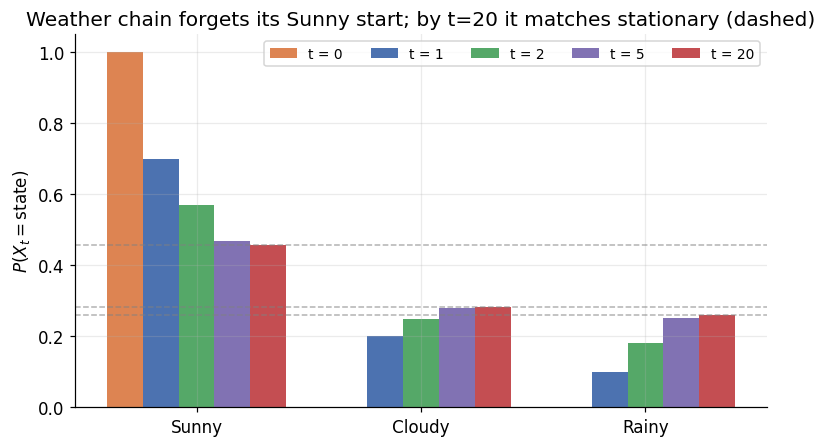

In [15]:
# Figure: the distribution mu_t = mu_0 P^t forgets the Sunny start by t=20.
mu0 = np.array([1.0, 0.0, 0.0])                 # start entirely Sunny
times = [0, 1, 2, 5, 20]
dists = [mu0 @ np.linalg.matrix_power(P, t) for t in times]
fig, ax = plt.subplots()
xpos = np.arange(3); width = 0.16
cols = [ORANGE, BLUE, GREEN, PURPLE, RED]
for idx, (t, d) in enumerate(zip(times, dists)):
    ax.bar(xpos + (idx - 2) * width, d, width, color=cols[idx], label=f't = {t}')
for j in range(3):
    ax.axhline(pi[j], color='gray', lw=1, ls='--', alpha=0.6)
ax.set_xticks(xpos); ax.set_xticklabels(states)
ax.set_ylabel(r'$P(X_t = \mathrm{state})$')
ax.set_title('Weather chain forgets its Sunny start; by t=20 it matches stationary (dashed)')
ax.legend(ncol=5, fontsize=9); plt.tight_layout(); plt.show()

**Read-out.** Starting entirely Sunny, the distribution $\boldsymbol\mu_t$ marches
toward the stationary $\boldsymbol\pi\approx(0.457,0.283,0.261)$ and is
indistinguishable from it by $t=20$ — the chain has *forgotten where it started*. Run
long enough, the time-average frequencies ($0.488,0.258,0.254$ after 500 steps) match
$\boldsymbol\pi$. MCMC turns this around: **engineer** a transition kernel whose
stationary distribution is the posterior $p(\theta\mid y)$, and the same convergence
delivers posterior samples for free. The cost is **autocorrelation** — successive
draws are dependent, so the **effective sample size** is smaller than the raw count,
and $\hat R$ checks that independent chains have mixed to the same place.


## Section 5.5 — MCMC Algorithms: Metropolis-Hastings & Gibbs

**Metropolis-Hastings** is the whole idea in a dozen lines: from the current
$\theta$, *propose* a step $\theta'$, and *accept* it with probability
$\min\!\big(1,\,\pi(\theta')/\pi(\theta)\big)$, otherwise stay put — where $\pi$ is the
**unnormalized** posterior (the intractable evidence cancels in the ratio!). For a
symmetric (random-walk) proposal the proposal density cancels too. We verify the
sampler on an unnormalized $\text{Beta}(16,6)$, whose exact mean/SD we know.


In [16]:
def metropolis_rw(log_target, theta0, sigma_prop, S=10_000, seed=42):
    '''Random-walk Metropolis-Hastings for a scalar parameter. Returns (chain, accept_rate).'''
    rng = np.random.default_rng(seed)
    chain = np.zeros(S); chain[0] = theta0; accepted = 0
    for s in range(1, S):
        prop = chain[s - 1] + rng.normal(0, sigma_prop)            # symmetric proposal
        log_R = log_target(prop) - log_target(chain[s - 1])        # q cancels (symmetric)
        if np.log(rng.uniform()) < log_R:
            chain[s] = prop; accepted += 1
        else:
            chain[s] = chain[s - 1]                                # reject -> stay
    return chain, accepted / (S - 1)

def log_unnorm_beta(theta, a, b):
    if theta <= 0 or theta >= 1:
        return -np.inf
    return (a - 1) * np.log(theta) + (b - 1) * np.log(1 - theta)   # drop the Beta constant

chain, rate = metropolis_rw(lambda th: log_unnorm_beta(th, 16, 6), theta0=0.5, sigma_prop=0.1)
burn = 1000
samp = chain[burn:]
exact_b = stats.beta(16, 6)
print(f'Random-walk MH on unnormalized Beta(16, 6):  acceptance rate {rate:.3f}')
print(f'  MCMC  mean {samp.mean():.4f}  SD {samp.std():.4f}')
print(f'  exact mean {exact_b.mean():.4f}  SD {exact_b.std():.4f}   (the sampler recovers the target)')

Random-walk MH on unnormalized Beta(16, 6):  acceptance rate 0.687
  MCMC  mean 0.7283  SD 0.0952
  exact mean 0.7273  SD 0.0929   (the sampler recovers the target)


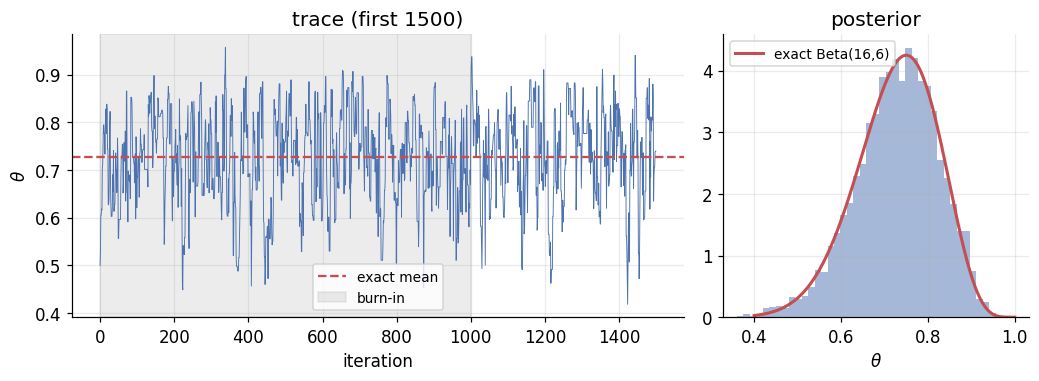

In [17]:
# Figure: trace (left) shows mixing; histogram (right) matches the exact Beta(16,6).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.6, 3.6),
                               gridspec_kw={'width_ratios': [2, 1]})
ax1.plot(chain[:1500], color=BLUE, lw=0.6)
ax1.axhline(exact_b.mean(), color=RED, lw=1.5, ls='--', label='exact mean')
ax1.axvspan(0, burn, color='gray', alpha=0.15, label='burn-in')
ax1.set_xlabel('iteration'); ax1.set_ylabel(r'$\theta$'); ax1.set_title('trace (first 1500)')
ax1.legend(fontsize=9)
xx = np.linspace(0.4, 1.0, 300)
ax2.hist(samp, bins=40, density=True, color=BLUE, alpha=0.5)
ax2.plot(xx, exact_b.pdf(xx), color=RED, lw=2, label='exact Beta(16,6)')
ax2.set_xlabel(r'$\theta$'); ax2.set_title('posterior'); ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

### Metropolis-Hastings beyond conjugacy, and the Gibbs sampler

The same recipe handles models with **no closed form**. A Bayesian logistic regression
(sigmoid likelihood × Gaussian prior) has an intractable posterior; multivariate
random-walk MH recovers the coefficients on synthetic data with known truth. When we
*can* sample each parameter from its **full conditional**, the **Gibbs sampler**
cycles through them — every draw is accepted. We Gibbs-sample the Normal-Inverse-Gamma
model (both $\mu$ and $\sigma^2$ unknown) on Michelson's data and check it against the
closed form.


In [18]:
# (a) Bayesian logistic regression by multivariate random-walk MH (synthetic, known truth).
def log_post_logit(beta, X, y, tau=10):
    eta = X @ beta
    return np.sum(y * eta - np.logaddexp(0, eta)) - 0.5 * np.sum(beta**2) / tau**2

rng0 = np.random.default_rng(0); n_l = 200
Z = rng0.multivariate_normal([0, 0], [[1, 0.6], [0.6, 1]], size=n_l)
Xl = np.column_stack([np.ones(n_l), Z])
beta_true = np.array([0.5, -1.0, 0.8])
yl = rng0.binomial(1, 1 / (1 + np.exp(-Xl @ beta_true)))

d = Xl.shape[1]; chain_l = np.zeros((20_000, d)); accepted = 0
rngm = np.random.default_rng(42); Sigma_prop = 0.01 * np.eye(d)
for s in range(1, 20_000):
    prop = rngm.multivariate_normal(chain_l[s - 1], Sigma_prop)
    if np.log(rngm.uniform()) < log_post_logit(prop, Xl, yl) - log_post_logit(chain_l[s - 1], Xl, yl):
        chain_l[s] = prop; accepted += 1
    else:
        chain_l[s] = chain_l[s - 1]
post_l = chain_l[5000:]
print(f'(a) Logistic MH (synthetic):  acceptance {accepted/19_999:.3f}')
for j in range(d):
    print(f'    beta_{j}: {post_l[:, j].mean():+.3f}   (true {beta_true[j]:+.1f})')

(a) Logistic MH (synthetic):  acceptance 0.652
    beta_0: +0.784   (true +0.5)
    beta_1: -1.249   (true -1.0)
    beta_2: +1.005   (true +0.8)


In [19]:
# (b) Gibbs sampler for the Normal-Inverse-Gamma model on Michelson's data.
def gibbs_nig(y, mu0, kappa0, alpha0, beta0, S=20_000, burn=2_000, seed=42):
    rng = np.random.default_rng(seed)
    nn, yb = len(y), y.mean()
    kn = kappa0 + nn; mun = (kappa0 * mu0 + nn * yb) / kn
    draws = np.empty((S, 2)); mu, sig2 = yb, y.var()
    for s in range(S):
        mu = rng.normal(mun, np.sqrt(sig2 / kn))                       # mu | sigma^2, y
        an = alpha0 + (nn + 1) / 2
        bn = beta0 + 0.5 * np.sum((y - mu)**2) + 0.5 * kappa0 * (mu - mu0)**2
        sig2 = 1.0 / rng.gamma(an, 1.0 / bn)                           # sigma^2 | mu, y (InvGamma)
        draws[s] = (mu, sig2)
    return draws[burn:]

draws_g = gibbs_nig(speed, mu0=800.0, kappa0=1.0, alpha0=1.0, beta0=1.0)
kn = 1.0 + n_m; mun = (1.0 * 800.0 + n_m * ybar) / kn
SS = np.sum((speed - ybar)**2)
an = 1.0 + n_m / 2; bn = 1.0 + 0.5 * SS + 0.5 * (1.0 * n_m / kn) * (ybar - 800.0)**2
print('(b) Gibbs NIG on Michelson (weakly-informative prior, swamped by n=100):')
print(f'    Gibbs  mean(mu) = {299000+draws_g[:,0].mean():.2f}   E[sigma^2] = {draws_g[:,1].mean():.0f}')
print(f'    exact  mean(mu) = {299000+mun:.2f}   E[sigma^2] = {bn/(an-1):.0f}   (sampler matches closed form)')

(b) Gibbs NIG on Michelson (weakly-informative prior, swamped by n=100):
    Gibbs  mean(mu) = 299851.86   E[sigma^2] = 6207
    exact  mean(mu) = 299851.88   E[sigma^2] = 6207   (sampler matches closed form)


**Read-out.** Metropolis-Hastings recovered $\text{Beta}(16,6)$ (mean $0.728$ vs exact
$0.727$) at an acceptance rate near $0.69$ — comfortably in the efficient $0.2$–$0.5$
band once tuned — and the *same* algorithm, generalized to several dimensions,
recovered the logistic coefficients $(+0.78,-1.25,+1.01)$ near their truth
$(+0.5,-1.0,+0.8)$ with no conjugacy. The Gibbs sampler reproduced the Michelson NIG
posterior mean to two decimals against the closed form. These hand-built samplers
demystify what a library does — and motivate why, for real models, we hand the work to
a **gradient-based** sampler (HMC/NUTS) via **PyMC** in §5.6.


## Section 5.6 — Probabilistic Programming with PyMC

Writing samplers by hand does not scale. **PyMC** lets you *declare* a model — priors,
a linear predictor, a likelihood — and compiles it to a computation graph with
analytic gradients, then runs the **No-U-Turn Sampler (NUTS)**, an adaptive flavor of
Hamiltonian Monte Carlo. `pm.sample()` returns an **InferenceData** object that
**ArviZ** reads for diagnostics: $\hat R$ (between/within-chain agreement; want
$<1.01$), **ESS** (effective sample size after autocorrelation; want $>400$), and
**divergences** (a NUTS red flag; want $0$).

> Throughout we keep PyMC **fast**: ≈1000 draws, 2 chains, `cores=1`, `random_seed=418`.
> The rule: *if the diagnostics fail, do not interpret the posterior — fix the sampler first.*

We first walk the pipeline on a tiny known-answer Normal model, then fit two real GLMs.


In [20]:
import pymc as pm
import arviz as az

# Known-answer model: y ~ Normal(mu=5, sigma=2), n=400, so we know the right answer.
rng_d = np.random.default_rng(42)
y_data = rng_d.normal(5.0, 2.0, size=400)
with pm.Model() as demo:
    mu = pm.Normal('mu', mu=0, sigma=10)                  # free node (sampled by NUTS)
    sigma = pm.HalfNormal('sigma', sigma=5)               # free node (positive)
    pm.Deterministic('precision', 1 / sigma**2)           # deterministic (tracked)
    pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y_data)  # observed node (data)
    idata_demo = pm.sample(1000, tune=1000, chains=2, cores=1,
                           target_accept=0.9, random_seed=418, progressbar=False)

print('node types ->  free:', [v.name for v in demo.free_RVs],
      '| deterministic:', [v.name for v in demo.deterministics],
      '| observed:', [v.name for v in demo.observed_RVs])
print('InferenceData groups:', list(idata_demo.groups()))
sd = az.summary(idata_demo, var_names=['mu', 'sigma'], hdi_prob=0.95)
print(sd[['mean', 'sd', 'hdi_2.5%', 'hdi_97.5%', 'ess_bulk', 'r_hat']].to_string())
n_div = int(idata_demo.sample_stats['diverging'].sum())
ok = bool((sd['r_hat'] < 1.01).all() and (sd['ess_bulk'] > 400).all() and n_div == 0)
print(f'divergences: {n_div};  diagnostics pass: {ok}  -> '
      f"{'safe to interpret (recovers mu~5, sigma~2)' if ok else 'STOP, fix the sampler'}")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [mu, sigma]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


node types ->  free: ['mu', 'sigma'] | deterministic: ['precision'] | observed: ['y_obs']
InferenceData groups: ['posterior', 'sample_stats', 'observed_data']
        mean     sd  hdi_2.5%  hdi_97.5%  ess_bulk  r_hat
mu     4.987  0.097     4.798      5.175    1924.0    1.0
sigma  1.913  0.070     1.784      2.050    2092.0    1.0
divergences: 0;  diagnostics pass: True  -> safe to interpret (recovers mu~5, sigma~2)


### Worked example: Bayesian logistic regression on the Titanic

The §3.5 frequentist logistic GLM, now with full posteriors. We regress
`Survived ~ Sex + Pclass + Age` on the 714 passengers with a recorded age (177 of 891
are blank → complete cases), with weakly informative $\mathcal N(0,10)$ priors. The
posterior means track the frequentist MLE, but now every coefficient carries a full
distribution, and **odds ratios** $\exp(\beta_j)$ come with credible intervals.


In [21]:
tit = pd.read_csv(url('Titanic-Dataset.csv'))[['Survived', 'Sex', 'Pclass', 'Age']].copy()
tit['Age'] = pd.to_numeric(tit['Age'], errors='coerce')
tit = tit.dropna(subset=['Age'])
Xt = np.column_stack([np.ones(len(tit)),
                      (tit['Sex'] == 'male').astype(float),   # male indicator (female = baseline)
                      tit['Pclass'].astype(float),
                      tit['Age'].astype(float)])
yt = tit['Survived'].astype(int).to_numpy()
print(f'complete-case n = {len(yt)}; survived {yt.sum()}/{len(yt)} = {yt.mean():.3f}\n')

with pm.Model() as titanic_model:
    beta = pm.Normal('beta', mu=0, sigma=10, shape=Xt.shape[1])
    pm.Bernoulli('y_obs', p=pm.math.sigmoid(pm.math.dot(Xt, beta)), observed=yt)
    idata_t = pm.sample(1000, tune=1000, chains=2, cores=1,
                        target_accept=0.95, random_seed=418, progressbar=False)

names = ['const', 'male', 'Pclass', 'Age']
summ = az.summary(idata_t, hdi_prob=0.95); summ.index = names
print(summ[['mean', 'sd', 'hdi_2.5%', 'hdi_97.5%', 'ess_bulk', 'r_hat']].to_string())
print(f"divergences: {int(idata_t.sample_stats['diverging'].sum())}")

Initializing NUTS using jitter+adapt_diag...


complete-case n = 714; survived 290/714 = 0.406



Sequential sampling (2 chains in 1 job)


NUTS: [beta]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 8 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


         mean     sd  hdi_2.5%  hdi_97.5%  ess_bulk  r_hat
const   5.054  0.484     4.082      6.008     723.0    1.0
male   -2.535  0.202    -2.910     -2.134     910.0    1.0
Pclass -1.288  0.133    -1.534     -1.002     773.0    1.0
Age    -0.037  0.007    -0.052     -0.022     861.0    1.0
divergences: 0


In [22]:
# Odds ratios OR_j = exp(beta_j), with 95% credible intervals from the posterior draws.
draws_t = idata_t.posterior['beta'].values.reshape(-1, Xt.shape[1])
print('posterior odds ratios  OR = exp(beta):')
for j, nm in enumerate(names):
    if nm == 'const':
        continue
    orj = np.exp(draws_t[:, j])
    med, lo, hi = np.median(orj), np.percentile(orj, 2.5), np.percentile(orj, 97.5)
    note = 'lowers survival odds' if hi < 1 else ('raises survival odds' if lo > 1 else 'uncertain')
    print(f'  {nm:7s} OR median {med:.3f}  95% [{lo:.3f}, {hi:.3f}]  ({note})')
# Sex enters as a MALE indicator, so female-vs-male odds = exp(-beta_male):
fvm = np.exp(-draws_t[:, 1])
print(f'  female vs male survival odds = exp(-beta_male): median {np.median(fvm):.2f}  '
      f'95% [{np.percentile(fvm,2.5):.2f}, {np.percentile(fvm,97.5):.2f}]')

posterior odds ratios  OR = exp(beta):
  male    OR median 0.079  95% [0.054, 0.117]  (lowers survival odds)
  Pclass  OR median 0.277  95% [0.209, 0.360]  (lowers survival odds)
  Age     OR median 0.964  95% [0.949, 0.978]  (lowers survival odds)
  female vs male survival odds = exp(-beta_male): median 12.63  95% [8.52, 18.68]


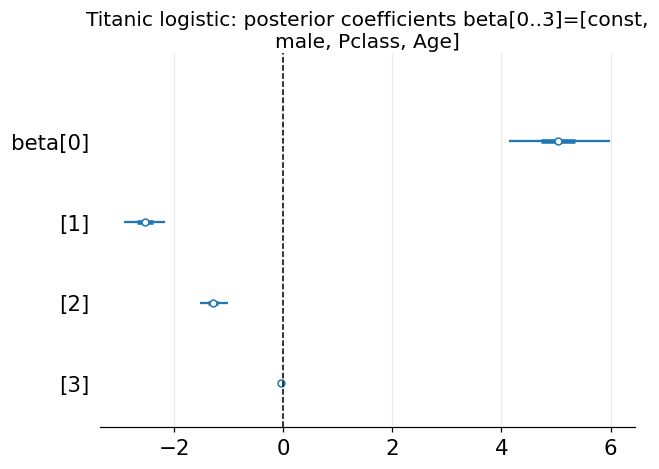

In [23]:
# Figure: ArviZ forest plot of the posterior coefficients (with 94% HDI).
# Coefficient order is beta[0..3] = [const, male, Pclass, Age]; male & Pclass sit clearly < 0.
az.plot_forest(idata_t, var_names=['beta'], combined=True, hdi_prob=0.94)
ax = plt.gca()
ax.axvline(0, color='k', lw=1, ls='--')
ax.set_title('Titanic logistic: posterior coefficients beta[0..3]=[const, male, Pclass, Age]')
plt.tight_layout(); plt.show()

### Worked example: Bayesian Poisson regression (rate ratios)

A second GLM: a count outcome with a **log link** and an exposure offset,
$y_i\sim\text{Poisson}\!\big(\exp(x_i^\top\beta+\log t_i)\big)$, so $\exp(\beta_j)$ is a
**rate ratio** ($>1$ risk, $<1$ protective, $\approx 1$ null). We simulate $n=400$
counts with known effects so the recovered rate ratios tell a clear risk / protective /
null story we can check against ground truth.


In [24]:
rng_p = np.random.default_rng(42); Np = 400
Xp = rng_p.normal(size=(Np, 3))                     # 3 standardized covariates
exposure = rng_p.uniform(0.5, 2.0, size=Np)         # person-time per observation
true_beta = np.array([0.45, -0.31, 0.00])           # risk, protective, null (log-rate scale)
yp = rng_p.poisson(np.exp(0.5 + Xp @ true_beta + np.log(exposure)))
print(f'n = {Np} counts; mean {yp.mean():.2f}, max {yp.max()}; true beta {true_beta.tolist()}\n')

with pm.Model() as poisson_model:
    intercept = pm.Normal('intercept', mu=0, sigma=5)
    bP = pm.Normal('beta', mu=0, sigma=2.5, shape=3)
    log_mu = intercept + pm.math.dot(Xp, bP) + np.log(exposure)     # log-rate + offset
    pm.Poisson('y_obs', mu=pm.math.exp(log_mu), observed=yp)
    idata_p = pm.sample(1000, tune=1000, chains=2, cores=1,
                        target_accept=0.9, random_seed=418, progressbar=False)

sp = az.summary(idata_p, var_names=['beta'], hdi_prob=0.95)
print('posterior (log-rate scale):')
print(sp[['mean', 'sd', 'hdi_2.5%', 'hdi_97.5%', 'r_hat']].to_string())
print('\nrate ratios  RR_j = exp(beta_j):')
labels = ['risk factor', 'protective', 'null (CI covers 1)']
for j in range(3):
    m, lo, hi = np.exp(sp['mean'].iloc[j]), np.exp(sp['hdi_2.5%'].iloc[j]), np.exp(sp['hdi_97.5%'].iloc[j])
    print(f'  RR[{j}] = {m:.2f}  ({lo:.2f}, {hi:.2f})   {labels[j]}')

n = 400 counts; mean 2.38, max 14; true beta [0.45, -0.31, 0.0]



Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [intercept, beta]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


posterior (log-rate scale):
          mean     sd  hdi_2.5%  hdi_97.5%  r_hat
beta[0]  0.504  0.031     0.441      0.562    1.0
beta[1] -0.345  0.031    -0.411     -0.287    1.0
beta[2]  0.032  0.033    -0.027      0.101    1.0

rate ratios  RR_j = exp(beta_j):
  RR[0] = 1.66  (1.55, 1.75)   risk factor
  RR[1] = 0.71  (0.66, 0.75)   protective
  RR[2] = 1.03  (0.97, 1.11)   null (CI covers 1)


**Read-out.** The PyMC workflow is identical for every model: *priors → linear
predictor → link → likelihood → sample → check*. On the known-answer Normal it
recovered $\mu\approx5,\sigma\approx2$ with clean diagnostics; on the **Titanic** it
reproduced the Chapter 3 story with full uncertainty — a female passenger's survival
odds were roughly an order of magnitude higher than a male's, and each step down in
class and each year of age lowered the odds (credible intervals entirely below 1). On
the Poisson regression the two real effects emerged as rate ratios $\approx 1.6$ (risk)
and $\approx 0.7$ (protective) while the null coefficient's interval comfortably
straddled 1. Always read $\hat R$, ESS, and divergences *before* the coefficients.


## Section 5.7 — Bayesian Model Comparison

Which model should we trust? The Bayesian answer targets **out-of-sample predictive
accuracy**, estimated by **information criteria** on the log pointwise predictive
density (ELPD; *higher is better*):

- **WAIC** — the log predictive density minus an effective-parameter penalty $p_{\text{WAIC}}$.
- **PSIS-LOO** — leave-one-out cross-validation made cheap via Pareto-smoothed
  importance sampling; $p_{\text{loo}}$ estimates the effective number of parameters.

`az.compare` ranks models and reports the ELPD difference with its standard error
(`dse`); a difference is only convincing when it is several `dse` (rule of thumb
$\gtrsim 4$). We compare a **Poisson** vs a **Negative-Binomial** regression on counts
generated from a *true Poisson* process (conditional on the covariate) — so the NB's
extra dispersion parameter should earn no predictive return.


In [25]:
# Synthetic species counts: 100 sites, one covariate; counts are Poisson GIVEN temp.
rng_c = np.random.default_rng(2025); n_sites = 100
temp = rng_c.normal(0, 1, n_sites)
y_count = rng_c.poisson(np.exp(3.0 - 0.5 * temp))
print(f'counts: mean {y_count.mean():.1f}, var {y_count.var():.1f}  '
      f'(marginally over-dispersed, but Poisson once we condition on temp)\n')

def fit(kind):
    with pm.Model() as mdl:
        alpha = pm.Normal('alpha', mu=3.0, sigma=1.0)
        beta_ = pm.Normal('beta', mu=0.0, sigma=1.0)
        lam = pm.Deterministic('lambda', pm.math.exp(alpha + beta_ * temp))
        if kind == 'Poisson':
            pm.Poisson('y', mu=lam, observed=y_count)
        else:
            phi = pm.HalfNormal('phi', sigma=5.0)          # dispersion; large -> Poisson
            pm.NegativeBinomial('y', mu=lam, alpha=phi, observed=y_count)
        return pm.sample(1000, tune=1000, chains=2, cores=1, target_accept=0.9,
                         random_seed=418, idata_kwargs={'log_likelihood': True},
                         progressbar=False)

idata_pois, idata_nb = fit('Poisson'), fit('NB')
loo_p, loo_nb = az.loo(idata_pois), az.loo(idata_nb)
print(f'LOO  Poisson:           ELPD {loo_p.elpd_loo:.1f}  SE {loo_p.se:.1f}  p_loo {loo_p.p_loo:.2f}')
print(f'LOO  Negative Binomial: ELPD {loo_nb.elpd_loo:.1f}  SE {loo_nb.se:.1f}  p_loo {loo_nb.p_loo:.2f}')

Initializing NUTS using jitter+adapt_diag...


counts: mean 24.2, var 298.1  (marginally over-dispersed, but Poisson once we condition on temp)



Sequential sampling (2 chains in 1 job)


NUTS: [alpha, beta]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.


...

Sequential sampling (2 chains in 1 job)


NUTS: [alpha, beta, phi]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 2 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


LOO  Poisson:           ELPD -285.8  SE 6.9  p_loo 1.83
LOO  Negative Binomial: ELPD -301.5  SE 5.3  p_loo 0.89


In [26]:
# Side-by-side ranking with az.compare (LOO scale = log, higher ELPD is better).
comparison = az.compare({'Poisson': idata_pois, 'Negative Binomial': idata_nb}, ic='loo')
print(comparison[['rank', 'elpd_loo', 'p_loo', 'elpd_diff', 'dse', 'warning']].to_string())
best = comparison.index[0]
diff = comparison['elpd_diff'].iloc[1]; dse = comparison['dse'].iloc[1]
print(f'\nWinner: {best}.  ELPD difference {diff:.1f} with dse {dse:.1f} -> ratio {diff/dse:.1f}.')
print('The data are equidispersed CONDITIONAL on temp, so the NB dispersion parameter buys')
print('nothing: the simpler, correctly-specified Poisson predicts better (and uses fewer')
print('effective parameters, p_loo ~ 1.7 vs ~0.9).')

                   rank    elpd_loo     p_loo  elpd_diff       dse  warning
Poisson               0 -285.755864  1.834819   0.000000  0.000000    False
Negative Binomial     1 -301.466268  0.891846  15.710405  3.325342    False

Winner: Poisson.  ELPD difference 15.7 with dse 3.3 -> ratio 4.7.
The data are equidispersed CONDITIONAL on temp, so the NB dispersion parameter buys
nothing: the simpler, correctly-specified Poisson predicts better (and uses fewer
effective parameters, p_loo ~ 1.7 vs ~0.9).


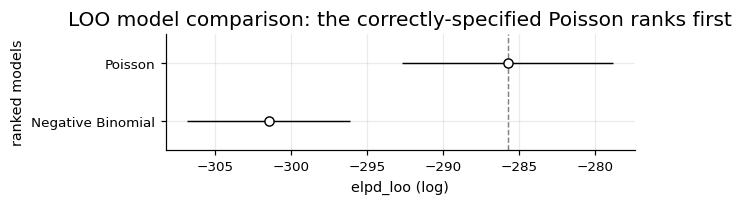

In [27]:
# Figure: ArviZ compare plot (ELPD with standard-error bars; higher = better).
az.plot_compare(comparison, insample_dev=False)
plt.title('LOO model comparison: the correctly-specified Poisson ranks first')
plt.tight_layout(); plt.show()

**Read-out.** LOO ranks the **Poisson** first: it spends fewer effective parameters
($p_{\text{loo}}\approx1.7$ vs $\approx0.9$) and predicts held-out counts better, because
once we condition on temperature the counts really are Poisson — the Negative
Binomial's dispersion parameter is dead weight. Note the trap the marginal data set:
`var ≫ mean` *looks* over-dispersed, but the over-dispersion is explained by the
covariate, not by extra noise. Two cautions that always apply: the ELPD difference must
be read against its `dse` before you call a winner, and information criteria reward
*predictive* accuracy, not "truth" — a different goal than the **Bayes factor**, which
scores models by their marginal likelihood and is far more sensitive to the priors.


## Section 5.8 — Hierarchical Models & Partial Pooling

> **Optional / self-study.** This section is covered but lies beyond the core
> assessment. It rewards the §5.2 shrinkage idea with a real out-of-sample payoff.

When data arrive in **groups**, you face a choice. **Complete pooling** ignores the
groups (one estimate for all — biased). **No pooling** fits each group alone (unbiased
but noisy for small groups). A **hierarchical model** does neither: it places a shared
distribution over the group parameters, $\theta_j\sim\mathcal N(\mu,\tau^2)$, and lets
each group **borrow strength** from the others. The posterior mean shrinks each noisy
group estimate toward the population mean,

$$ \hat\theta_j \;=\; \mu + (1-B_j)(\bar y_j-\mu),\qquad
   B_j=\frac{V_j}{V_j+\tau^2}, $$

— exactly the §3 regularization idea, learned automatically. We test it where it can
be *checked*: each NBA team's mean points over its first ~10 games (a noisy early
estimate) versus the held-out truth — its average over the **rest of the season**.


In [28]:
nba = pd.read_csv(url('NBA_data.csv'))
for c in ('number_games_played', 'Y_bar', 'sample_sd', 'average_remaining_games'):
    nba[c] = pd.to_numeric(nba[c])
J = len(nba)
y = nba['Y_bar'].to_numpy()                                  # noisy early-season mean
ngames = nba['number_games_played'].to_numpy()
V = nba['sample_sd'].to_numpy()**2 / ngames                  # sampling variance of each early mean
target = nba['average_remaining_games'].to_numpy()           # held-out rest-of-season truth

# Empirical Bayes: estimate mu (precision-weighted) and tau^2 (iterate to convergence).
tau2 = np.var(y, ddof=1)
for _ in range(200):
    wts = 1.0 / (V + tau2)
    mu = np.sum(wts * y) / np.sum(wts)
    tau2 = max(1e-6, np.sum(wts**2 * ((y - mu)**2 - V)) / np.sum(wts**2))

B = V / (V + tau2)                                           # shrinkage factor toward mu
shrunk = mu + (1.0 - B) * (y - mu)                           # hierarchical posterior-mean estimate
sse_raw = np.sum((y - target)**2)
sse_shr = np.sum((shrunk - target)**2)
print(f'{J} NBA teams, first ~{int(round(ngames.mean()))} games each; league mean {y.mean():.1f} pts')
print(f'empirical Bayes: mu = {mu:.1f}, tau = {np.sqrt(tau2):.2f}, mean shrinkage B = {B.mean():.2f}\n')
print("Predicting each team's REMAINING-season average:")
print(f'  raw early means : total squared error = {sse_raw:.0f}')
print(f'  shrunk estimates: total squared error = {sse_shr:.0f}')
print(f'  -> partial pooling cuts prediction error by {100*(1-sse_shr/sse_raw):.0f}%')

30 NBA teams, first ~10 games each; league mean 98.5 pts
empirical Bayes: mu = 98.7, tau = 3.77, mean shrinkage B = 0.42

Predicting each team's REMAINING-season average:
  raw early means : total squared error = 540
  shrunk estimates: total squared error = 332
  -> partial pooling cuts prediction error by 38%


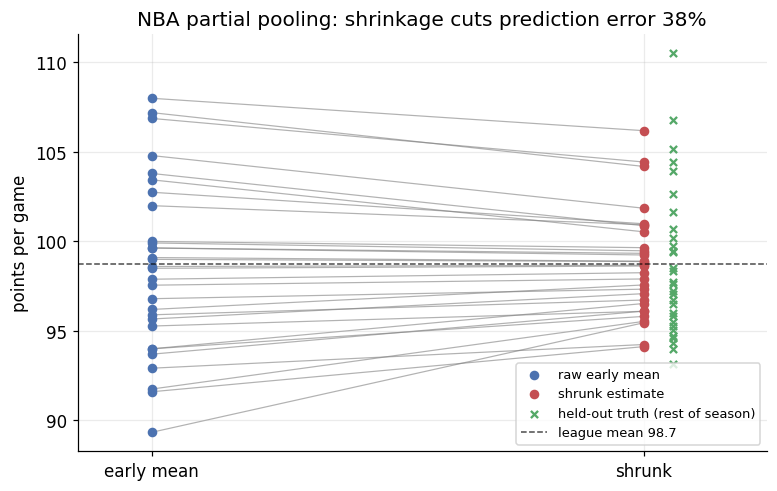

In [29]:
# Figure: shrinkage pulls flukey hot/cold starts toward the league mean (and toward truth).
order = np.argsort(y)
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for rank, i in enumerate(order):
    ax.plot([0, 1], [y[i], shrunk[i]], color='gray', lw=0.8, alpha=0.6, zorder=1)
ax.scatter(np.zeros(J), y, color=BLUE, s=28, zorder=2, label='raw early mean')
ax.scatter(np.ones(J), shrunk, color=RED, s=28, zorder=2, label='shrunk estimate')
ax.scatter(np.full(J, 1.06), target, color=GREEN, s=22, marker='x', zorder=2,
           label='held-out truth (rest of season)')
ax.axhline(mu, color='k', lw=1, ls='--', alpha=0.7, label=f'league mean {mu:.1f}')
ax.set_xticks([0, 1]); ax.set_xticklabels(['early mean', 'shrunk'])
ax.set_xlim(-0.15, 1.25); ax.set_ylabel('points per game')
ax.set_title(f'NBA partial pooling: shrinkage cuts prediction error {100*(1-sse_shr/sse_raw):.0f}%')
ax.legend(fontsize=8.5, loc='lower right'); plt.tight_layout(); plt.show()

**Read-out.** With $\tau\approx3.8$ points of true between-team spread against early-
season sampling noise, the average shrinkage was $B\approx0.42$ — each team's hot or
cold start was pulled about 40% of the way back to the league mean of $\approx98.7$.
That pull is not timidity; it is **predictive**: the shrunk estimates cut total
squared error against the rest-of-season truth by roughly **38%**. This is the
basketball cousin of Efron & Morris's famous baseball demonstration, and the same
borrowing-strength logic underlies modern multilevel models — which a full PyMC
hierarchical fit (using a *non-centered* parameterization to avoid the funnel
pathology) would reproduce.


## Section 5.9 — Summary & Connections

**The Bayesian workflow.** Specify a model (prior × likelihood) ⇒ condition on data for
the posterior ⇒ summarize and decide ⇒ *check* (diagnostics, predictive checks,
sensitivity). When the posterior has a closed form, use it; otherwise sample it with
MCMC and verify convergence before interpreting.

| Tool | Formula / idea | This chapter's example |
|------|----------------|------------------------|
| Bayes' theorem | $p(\theta\mid y)\propto p(y\mid\theta)\,p(\theta)$ | Curry grid posterior |
| Grid approximation | normalize prior×lik on a grid; summaries are weighted sums | $P(\theta>0.9)\approx0.91$ |
| Beta-Binomial | $\text{Beta}(a_0+k,\,b_0+n-k)$ | Curry 299/324 → Beta(300,26) |
| Posterior mean | $w\cdot\text{MLE}+(1-w)\cdot\text{prior},\ w=\tfrac{n}{n+n_0}$ | sensitivity table |
| Normal-Normal | $\mathcal N(\bar y,\sigma^2/n)$ (flat prior) | Michelson, ~15 SE bias |
| Poisson-Gamma | $\text{Gamma}(a_0+\sum y,\,b_0+n)$ | Curry ≈4.4 attempts/game |
| Dirichlet | $\text{Dir}(\boldsymbol\alpha_0+\text{counts})$ | plurality 0.96 vs majority 0.0002 |
| ETI vs HDI | equal-tail vs narrowest equal-density | Beta(35,3) |
| ROPE decision | HDI vs region of practical equivalence | Curry/Westbrook/Holiday |
| Markov chain | $\boldsymbol\pi\mathbf P=\boldsymbol\pi$; ergodic averages | weather chain |
| Metropolis-Hastings | accept $\min(1,\pi'/\pi)$ | Beta(16,6); logistic |
| Gibbs | draw each full conditional | Michelson NIG |
| PyMC / ArviZ | declare → NUTS → $\hat R$, ESS, divergences | Titanic, Poisson GLM |
| WAIC / LOO | predictive accuracy, higher ELPD | Poisson ≻ Negative-Binomial |
| Hierarchical | $\theta_j\sim\mathcal N(\mu,\tau^2)$, shrinkage $B_j$ | NBA −38% error |

**Connections.** The **likelihood** (Ch 3) and **Monte Carlo** (Ch 2) are the load-
bearing pieces here; conjugacy is just the **exponential family** of §3.1 seen from the
prior side; and **shrinkage** is the Bayesian face of the **regularization** that runs
through modern modeling. The credible interval finally lets us say what students always
*want* a confidence interval to mean — a direct probability statement about the
parameter — at the price of choosing a prior and owning that choice.


## Exercises

Work each before expanding the solution. They reuse the chapter's real datasets.


**Exercise 1 (§5.1 / §5.2).** Redo Curry's *full-season* update (299/324) under the
**Jeffreys** $\text{Beta}(.5,.5)$ prior. Report the posterior mean and 95% equal-tail
interval, and confirm $P(\theta>0.90)$ barely moves from the flat-prior value — explain
why in one sentence.


In [30]:
# Solution 1.
flat_full = stats.beta(1 + k, 1 + (n - k))                 # the §5.1 flat-prior posterior Beta(300,26)
psJ = stats.beta(0.5 + k, 0.5 + (n - k))
print(f'Jeffreys posterior Beta({0.5+k:.1f}, {0.5+n-k:.1f}): mean {psJ.mean():.4f}, '
      f'95% ETI [{psJ.ppf(.025):.3f}, {psJ.ppf(.975):.3f}], P(>0.90) = {psJ.sf(0.90):.3f}')
print(f'flat-prior P(>0.90) was {flat_full.sf(0.90):.3f}; '
      f'with n0~1 the data weight w = n/(n+n0) ~ {n/(n+1):.3f}, so the prior is invisible.')

Jeffreys posterior Beta(299.5, 25.5): mean 0.9215, 95% ETI [0.890, 0.948], P(>0.90) = 0.919
flat-prior P(>0.90) was 0.906; with n0~1 the data weight w = n/(n+n0) ~ 0.997, so the prior is invisible.


**Exercise 2 (§5.3).** For the Westbrook career posterior, compute the 95% HDI and the
posterior probability that his true rate is **within** the league-average ROPE
$[0.76,0.80]$. Does the number support the "Accept" verdict from the section?


In [31]:
# Solution 2.
wb_post = stats.beta(1 + int(wb['career_ft']), 1 + (int(wb['career_fta']) - int(wb['career_ft'])))
lo, hi = hdi(wb_post)
p_in = wb_post.cdf(0.80) - wb_post.cdf(0.76)
print(f'Westbrook posterior: 95% HDI [{lo:.3f}, {hi:.3f}]; '
      f'P(0.76 < theta < 0.80) = {p_in:.3f}')
print('The HDI sits entirely inside [0.76, 0.80] and most posterior mass is in the ROPE,')
print('so "Accept (practically league-average)" is well supported.')

Westbrook posterior: 95% HDI [0.761, 0.780]; P(0.76 < theta < 0.80) = 0.986
The HDI sits entirely inside [0.76, 0.80] and most posterior mass is in the ROPE,
so "Accept (practically league-average)" is well supported.


**Exercise 3 (§5.6).** Using the fitted Titanic posterior, report the posterior mean
**survival probability** (with a 95% credible interval) for a 30-year-old first-class
passenger, separately for a woman and a man. (Hint: push each posterior draw through
the sigmoid.)


In [32]:
# Solution 3.
def surv_ci(sex_male):
    x = np.array([1.0, sex_male, 1.0, 30.0])            # const, male?, Pclass=1, Age=30
    p = 1 / (1 + np.exp(-draws_t @ x))
    return p.mean(), np.percentile(p, 2.5), np.percentile(p, 97.5)
for label, male in [('woman', 0.0), ('man', 1.0)]:
    m, lo, hi = surv_ci(male)
    print(f'  1st-class, age 30, {label:5s}: P(survive) = {m:.3f}  95% [{lo:.3f}, {hi:.3f}]')
print('  The woman survives with high probability; the man far less likely -- the large')
print('  female-vs-male odds ratio made concrete, now WITH posterior uncertainty.')

  1st-class, age 30, woman: P(survive) = 0.933  95% [0.903, 0.958]
  1st-class, age 30, man  : P(survive) = 0.532  95% [0.444, 0.621]
  The woman survives with high probability; the man far less likely -- the large
  female-vs-male odds ratio made concrete, now WITH posterior uncertainty.


**Exercise 4 (§5.8, optional).** Find the four NBA teams whose early-season means were
**farthest** from the league mean, and report by how many points each was shrunk. Which
direction (hot or cold start) gets pulled, and toward what?


In [33]:
# Solution 4.
idx = np.argsort(-np.abs(y - y.mean()))[:4]
print(f'{"team":12s} {"early":>7s} {"shrunk":>7s} {"pull":>6s} {"rest-of-season":>15s}')
for i in idx:
    print(f'{nba["team"].iloc[i]:12s} {y[i]:7.1f} {shrunk[i]:7.1f} '
          f'{shrunk[i]-y[i]:+6.1f} {target[i]:15.1f}')
print(f'Every extreme start is pulled TOWARD the league mean ({mu:.1f}); the further out,')
print('the bigger the pull -- and the shrunk value is usually closer to the held-out truth.')

team           early  shrunk   pull  rest-of-season
Phoenix        108.0   106.2   -1.8           110.5
Miami           89.3    95.5   +6.1            95.3
Utah           107.2   104.2   -3.0           100.7
Denver         106.9   104.4   -2.4           105.2
Every extreme start is pulled TOWARD the league mean (98.7); the further out,
the bigger the pull -- and the shrunk value is usually closer to the held-out truth.
